In [1]:
# --LIBRARIES IMPORTATION--
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Scikit-Learn modules
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score,roc_curve, auc, ConfusionMatrixDisplay

# Ensemble & Advanced Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb



# Machine Learning Project Notebook

## Step I : EDA, split and preprocessing

In [4]:
#-- DATA LOADING & DATA OVERVIEW --
# Loading the dataset
df = pd.read_csv("train.csv")

# Drop unnecessary columns (since ID isn't predicitve)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print("5 first rows of data")
print(df.head())

5 first rows of data
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0                       3              1

In [5]:
print("\nInfos on data")
# Checking for data-types and number of entries
df.info()


Infos on data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding         

In [6]:
print("\nMissing values count")
# Checking for any missing values to decide on how to handle them
print(df.isnull().sum())


Missing values count
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64


In [7]:
print("\nDescriptives stats")
#Checking for ditribution of numerical features
print(df.describe())


Descriptives stats
                 Age  Flight Distance  Inflight wifi service  \
count  103904.000000    103904.000000          103904.000000   
mean       39.379706      1189.448375               2.729683   
std        15.114964       997.147281               1.327829   
min         7.000000        31.000000               0.000000   
25%        27.000000       414.000000               2.000000   
50%        40.000000       843.000000               3.000000   
75%        51.000000      1743.000000               4.000000   
max        85.000000      4983.000000               5.000000   

       Departure/Arrival time convenient  Ease of Online booking  \
count                      103904.000000           103904.000000   
mean                            3.060296                2.756901   
std                             1.525075                1.398929   
min                             0.000000                0.000000   
25%                             2.000000                2.00000

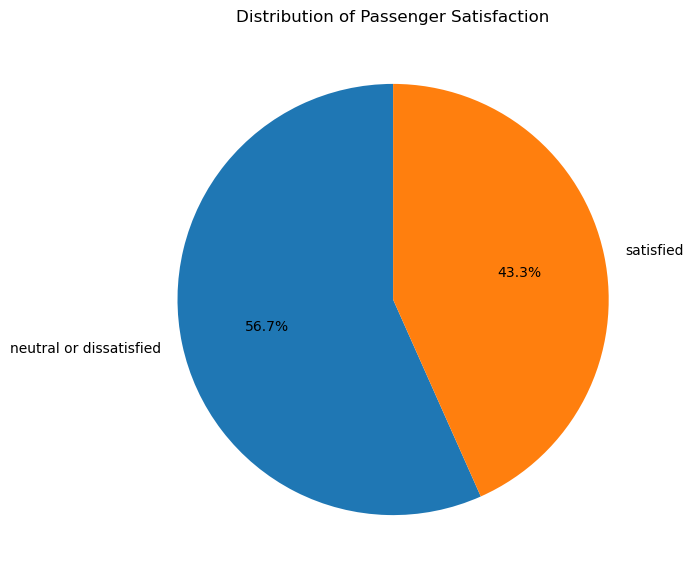

In [8]:
# -- TARGET DISTRIBUTION --
# Visualizing the balance of the target data 
plt.figure(figsize=(7, 7))
satisfaction_counts = df['satisfaction'].value_counts()
labels = satisfaction_counts.index
plt.pie(satisfaction_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passenger Satisfaction')
plt.show()

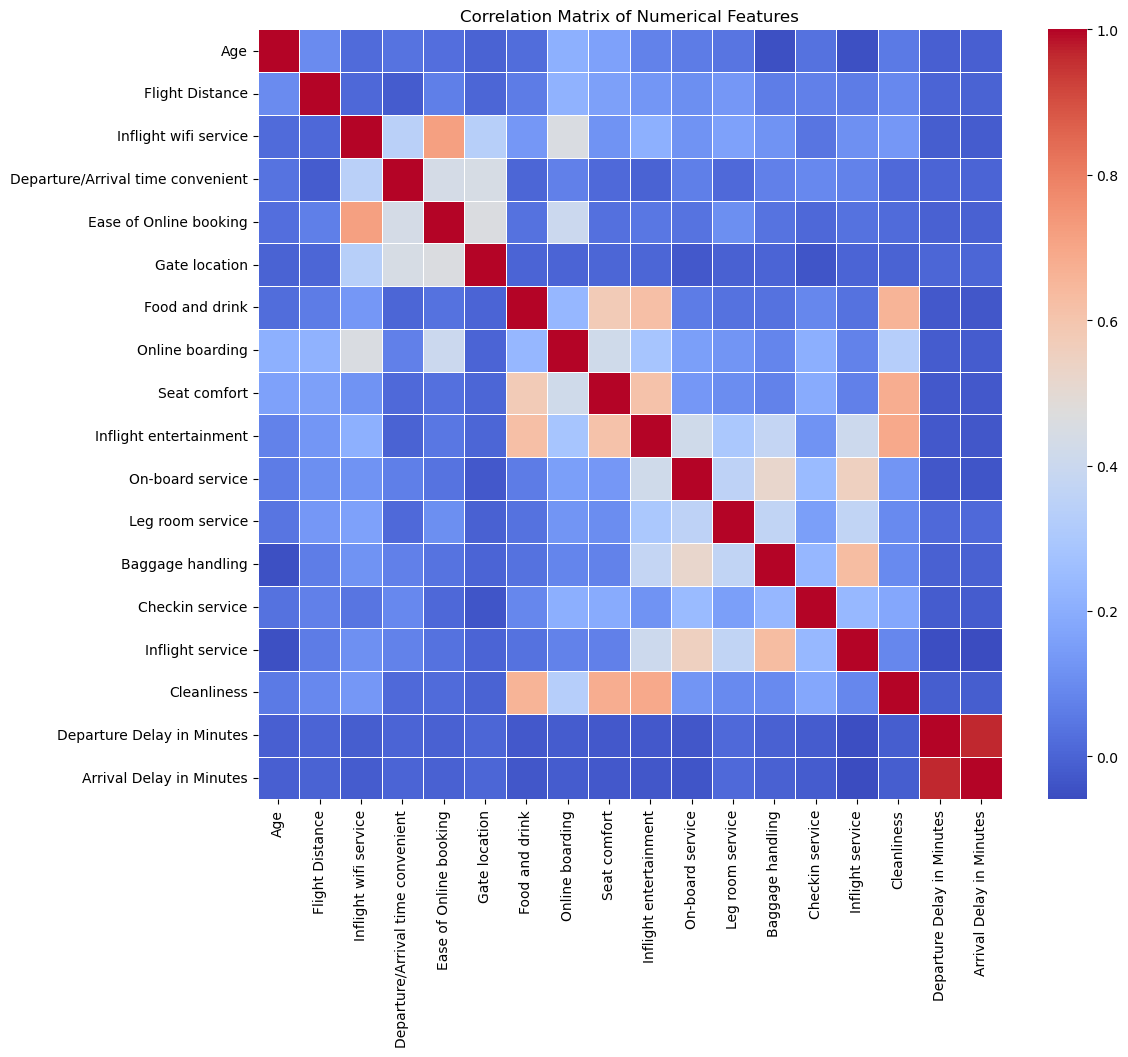

In [9]:
# -- CORRELATION MATRIX --
# Check for multicollinearity among numercial features
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [13]:
# -- DATA SPLITTING --
# Separating features (X) and target (Y)
X= df.drop('satisfaction', axis=1)
y= df['satisfaction']

# Split into Train (80%) and Test (20%) sets wit h fixed seed for reproducibility 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# -- PREPROCESSING PIPELINE DEFINITION --
# Identifying colmumns types
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 1. Numerical Features Pipeline
# - Imputing missing values with Median (best for outliers like delays)
# - Scaling features (with StandardScaler) for linear models
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Features Pipeline
# - Iputing missing values with the most frequent category.
# - OneHotEncode to conert into binary columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combining both pipelines into a Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, numerical_features),
        ('cat',categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

Training set shape: (83123, 22)
Test set shape: (20781, 22)


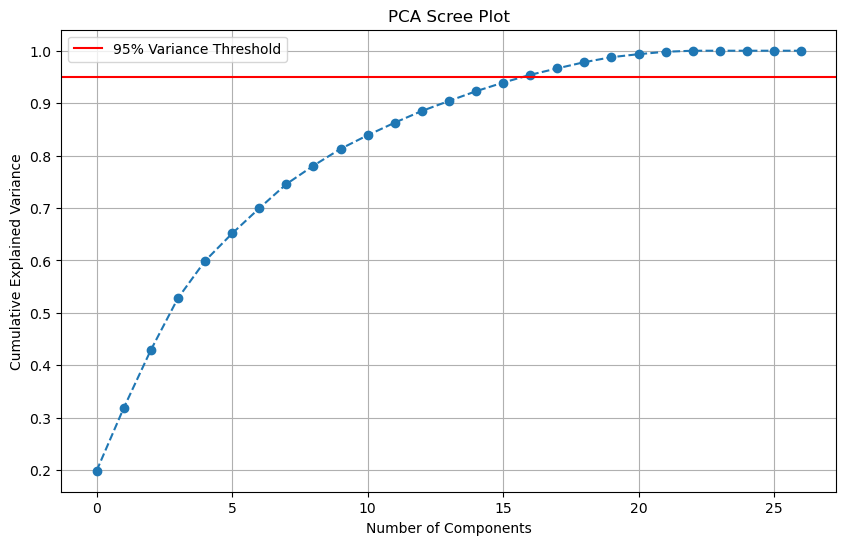

In [15]:
# -- DIMENSION REDUCTION ANALYSIS (PCA) --
# The polan is to analyze the explainde variance to see if it's relevant to reduce features.

# We fit the preprocessor on the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Then we fit the PCA
pca = PCA()
pca.fit(X_train_preprocessed)

# A,d we plot the cumulative explained variance (scree plot)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.legend(loc='best')
plt.show()

In [19]:
# -- EVALUATION FUNCTION --
# A unififed function to compute keys metrics for any models we will use
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    # Extract metrics for the positive class ('satisfied' here)
    # We need to make sure 'satisfied' is the label, otherwise the key must be adjust
    precision = report['satisfied']['precision']
    recall = report['satisfied']['recall']
    f1 = report['satisfied']['f1-score']

    roc_auc = None
    if y_proba is not None:
        try:
            # Calculting the AUC-ROC (Area Under Curve)
            roc_auc = roc_auc_score(y_true, y_proba[:, 1])
        except ValueError:
            pass

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (Satisfied)': precision,
        'Recall (Satisfied)': recall,
        'F1-Score (Satisfied)': f1,
        'ROC AUC': roc_auc
      }

results = [] # The list that will store all results

In [21]:
# -- MODEL 1 : BASELINE(Logistic Regression) --
# Simple linear model to establish a banchmark 
# We keep 95% variance regarding PCA for this baseline as tested before
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca',PCA(n_components=0.95)),
    ('classifier', LogisticRegression(random_state=42,solver='liblinear',max_iter=1000))
])

print("Training Baseline Model...")
logreg_model.fit(X_train, y_train)

# Predict
y_pred = logreg_model.predict(X_test)
y_proba= logreg_model.predict_proba(X_test)

# Evaluate
baseline_metrics = evaluate_model("Logistic regression (Baseline)", y_test, y_pred, y_proba)
results.append(baseline_metrics)
print(baseline_metrics)

Training Baseline Model...
{'Model': 'Logistic regression (Baseline)', 'Accuracy': 0.847216207112266, 'Precision (Satisfied)': 0.843855759131754, 'Recall (Satisfied)': 0.7974194971327746, 'F1-Score (Satisfied)': 0.81998072234507, 'ROC AUC': 0.9095987379530832}


In [25]:
# -- MODEL OPTIMIZATION (GridSearchCV) --
print("Starting Grid Search for Logistic Regression...")
start_time = time.time()
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)
print(f"GridSearchCV ended in {time.time() - start_time:.2f} seconds.")
print(f"Best params : {grid_search.best_params_}")

# Evaluate Best Model
best_model = grid_search.best_estimator_
y_pred_gs = best_model.predict(X_test)
y_proba_gs = best_model.predict_proba(X_test)

logreg_gs_metrics = evaluate_model("Logistic Regression (GridSearch)", y_test, y_pred_gs, y_proba_gs)
results.append(logreg_gs_metrics)


# -- MODEL 2: RANDOM FOREST(Ensemble - Bagging) --
# Non-linear model to capture complex interactions
print("\nTraining Random Forest...")
start_time = time.time()


rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,max_depth=16,min_samples_leaf=5))
])

rf_model.fit(X_train, y_train)
end_time = time.time()
print(f"Random Forest training ended in {end_time - start_time:.2f} seconds.")
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
results.append(rf_metrics)
print(rf_metrics)

Starting Grid Search for Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
GridSearchCV ended in 6.69 seconds.
Best params : {'classifier__C': 0.01, 'classifier__penalty': 'l2'}

Training Random Forest...
Random Forest training ended in 3.09 seconds.
{'Model': 'Random Forest', 'Accuracy': 0.9594822193349695, 'Precision (Satisfied)': 0.9662208116073453, 'Recall (Satisfied)': 0.9400088222320248, 'F1-Score (Satisfied)': 0.9529346003353829, 'ROC AUC': 0.9933053321177188}


In [26]:
# -- MODEL 3: VOTING CLASSIFIER (Ensemble) -- 
# Combining models to reduce variance
clf1 = grid_search.best_estimator_.named_steps['classifier']
clf2 = DecisionTreeClassifier(max_depth=10, random_state=42)
clf3 = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)


voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('dt', clf2), ('rf', clf3)],
    voting='soft',
)

voting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', voting_clf)
])

print("Training Voting Classifier...")
voting_model.fit(X_train, y_train)
y_pred_vote = voting_model.predict(X_test)
y_proba_vote = voting_model.predict_proba(X_test)

voting_metrics = evaluate_model("Voting Classifier (Soft)", y_test, y_pred_vote, y_proba_vote)
results.append(voting_metrics)

Training Voting Classifier...


In [31]:
# -- MODEL 4 : XGBOOST (Advanced - Out of Scope) --
# Scientific Ref: Chen & Guestrin (2016). Gradient Boosting for state-of-the-art performance.

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

print("\nTraining XGBoost...")
start_time = time.time()
xgb_pipeline.fit(X_train, y_train_enc)
print(f"XGBoost training ended in {time.time() - start_time:.2f} seconds.")

# Prediction & Inverse Transform
y_pred_enc = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)
y_pred_xgb = le.inverse_transform(y_pred_enc) # Decoding back to strings

xgb_metrics = evaluate_model("XGBoost (Out of Scope)", y_test, y_pred_xgb, y_proba_xgb)
results.append(xgb_metrics)
print(xgb_metrics)


Training XGBoost...
XGBoost training ended in 1.09 seconds.
{'Model': 'XGBoost (Out of Scope)', 'Accuracy': 0.9634762523458928, 'Precision (Satisfied)': 0.9736632083000798, 'Recall (Satisfied)': 0.9417732686369652, 'F1-Score (Satisfied)': 0.9574527720163686, 'ROC AUC': 0.994994119579017}


In [37]:
# -- ROBUSTNESS & DIMENSIONALITY REUDCTION --

# 1. PCA Analysis (Dimensionality Reduction)
# We test XGBoost with PCA (95% variance) to check efficenciy vs accuracy trade-off
print("\n Training XGBoost with PCA...")
xgb_pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),  # Keep that 95% variance
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,learning_rate=0.1,max_depth=6,
        random_state=42,eval_metric='logloss'
    ))
])

xgb_pca_pipeline.fit(X_train, y_train_enc) 
y_pred_enc_pca = xgb_pca_pipeline.predict(X_test)
y_proba_pca = xgb_pca_pipeline.predict_proba(X_test)
y_pred_pca = le.inverse_transform(y_pred_enc_pca) # We decode labels

# We add PCA results to the list
metrics_pca = evaluate_model("XGBoost + PCA", y_test, y_pred_pca, y_proba_pca)
results.append(metrics_pca)

# 2. Cross-Validation (Robustness)
# We perform 5-Fold CV to make sure our results are not due to a lucky split.
print("\nRunning 5-Fold Cross-Validation on Standard XGBoost...")
cv_scores = cross_val_score(xgb_pipeline, X_train, y_train_enc, cv=5, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



 Training XGBoost with PCA...

Running 5-Fold Cross-Validation on Standard XGBoost...
Mean CV Accuracy: 0.9632 (+/- 0.0031)


# Step IV comparison


-- Model Performance Leaderboard --
| Model                            |   Accuracy |   Precision (Satisfied) |   Recall (Satisfied) |   F1-Score (Satisfied) |   ROC AUC |
|:---------------------------------|-----------:|------------------------:|---------------------:|-----------------------:|----------:|
| XGBoost (Out of Scope)           |     0.9635 |                  0.9737 |               0.9418 |                 0.9575 |    0.9950 |
| Random Forest                    |     0.9595 |                  0.9662 |               0.9400 |                 0.9529 |    0.9933 |
| Voting Classifier (Soft)         |     0.9472 |                  0.9479 |               0.9301 |                 0.9389 |    0.9872 |
| XGBoost + PCA                    |     0.9317 |                  0.9405 |               0.9004 |                 0.9200 |    0.9800 |
| Logistic regression (Baseline)   |     0.8472 |                  0.8439 |               0.7974 |                 0.8200 |    0.9096 |
| Logistic 

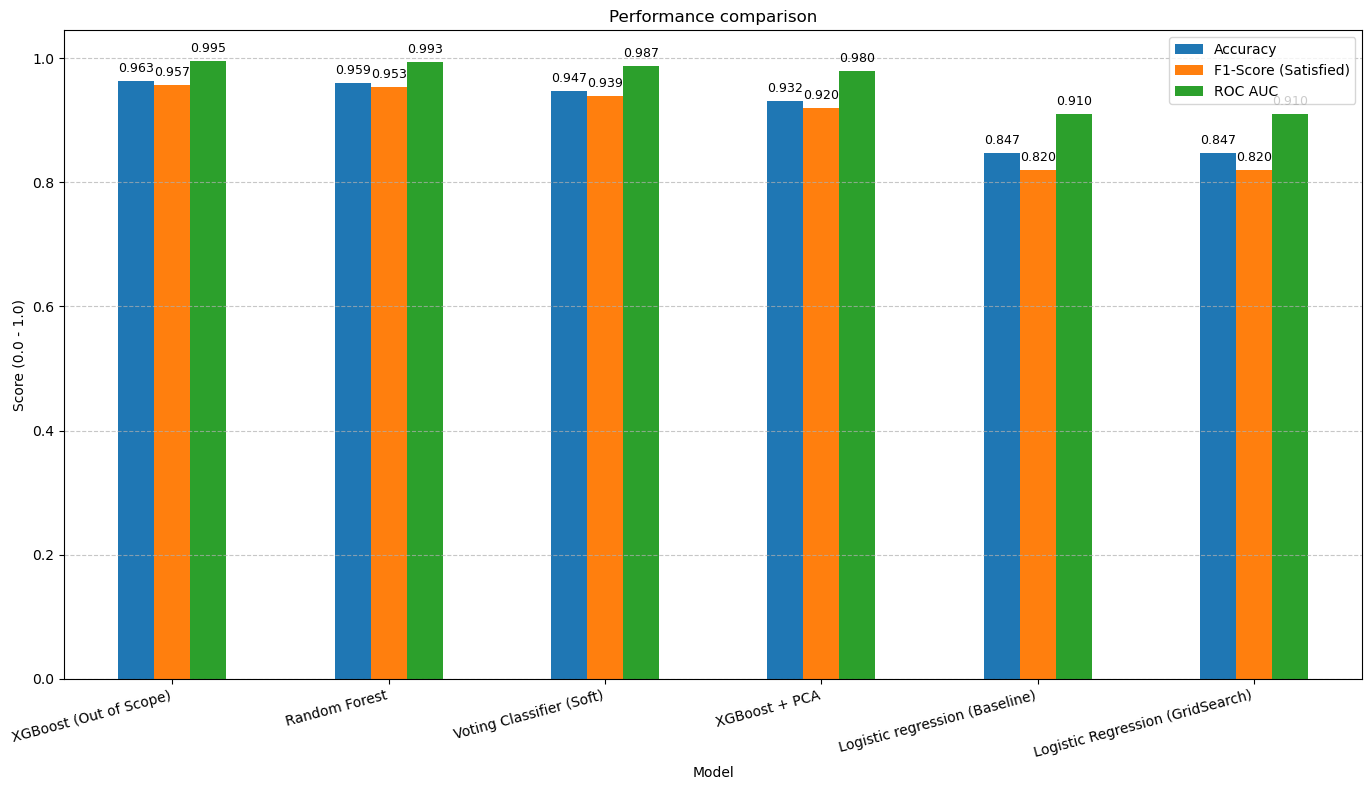

In [40]:
# -- FINAL COMPARISON & RESULTS --
# We aggregate all results, remove the duplicates, and then display the leaderboard.

# Create the Dataframe and clean the duplicates (keeping the laterst run)
results_df = pd.DataFrame(results).drop_duplicates(subset='Model', keep='last').set_index('Model')
results_df = results_df.sort_values(by='ROC AUC', ascending=False)

print("\n-- Model Performance Leaderboard --")
print(results_df.to_markdown(floatfmt=".4f"))

# Plotting results
plot_df = results_df[['Accuracy', 'F1-Score (Satisfied)', 'ROC AUC']]
ax = plot_df.plot(
    kind='bar',
    figsize=(14, 8),
    title='Performance comparison'
)

plt.ylabel('Score (0.0 - 1.0)')
plt.xlabel('Model')
plt.xticks(rotation=15, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() 
plt.show()